## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import healsparse as hs
import healpy as hp
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..'))

In [172]:
import lsst.daf.butler as dafButler
import lsst.afw.display as afwDisplay

import lsst.geom
import lsst.sphgeom as sphgeom
import shapely

from bright_objects_masks import tract2htm_id, hpix2htm_id

In [4]:
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.collections import PatchCollection
afwDisplay.setDefaultBackend('firefly')
afw_display = afwDisplay.Display(frame=1)

## Read in Abell 360 field
We will take a look at one of the patches in the Abell 360 field: `TRACT = 10463` and `PATCH = 64`. We are able to grab the vertices of the tract but not the patch, so we will grab all of the stars in the Monster catalog that overlap with the tract.

The Monster catalog is by default saved in htm7 format (HTM at `depth = 7`). Each htm ID corresponds to a wedge on the sky.

In [204]:
skymap_name =  'lsst_cells_v1'
repo = 'dp1'
collection = 'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260'
instrument = "LSSTComCam"

butler = dafButler.Butler(repo, collections=collection, skymap=skymap_name, 
                                     instrument=instrument)

In [211]:
TRACT, PATCH = 10463, 64

coadd = butler.get("deep_coadd", tract=TRACT, patch=PATCH, band=BAND)
skymap = butler.get('skyMap')

In [212]:
htm_ids = tract2htm_id(7, TRACT, skymap)

ID: 255060, area: 0.2707902377562024
ID: 255061, area: 0.27120704243404903
ID: 255062, area: 0.27077733603052745
ID: 255063, area: 0.27116238837338846
ID: 255068, area: 0.2716797952053259
ID: 255070, area: 0.27123950396272645
ID: 255071, area: 0.27132549646834886
ID: 255080, area: 0.2709161368861408
ID: 255082, area: 0.2713463486003024
ID: 255083, area: 0.2713012279826776
ID: 255088, area: 0.27174252419786316
ID: 255089, area: 0.272184090613924
ID: 255090, area: 0.2721935635994725
ID: 255091, area: 0.2718293993023989
ID: 255176, area: 0.2721724810012311
ID: 255177, area: 0.27218228098131714
ID: 255179, area: 0.2718985845148062
ID: 255181, area: 0.27202307033365936
ID: 255204, area: 0.27204842913949717
ID: 255220, area: 0.27234801007309417


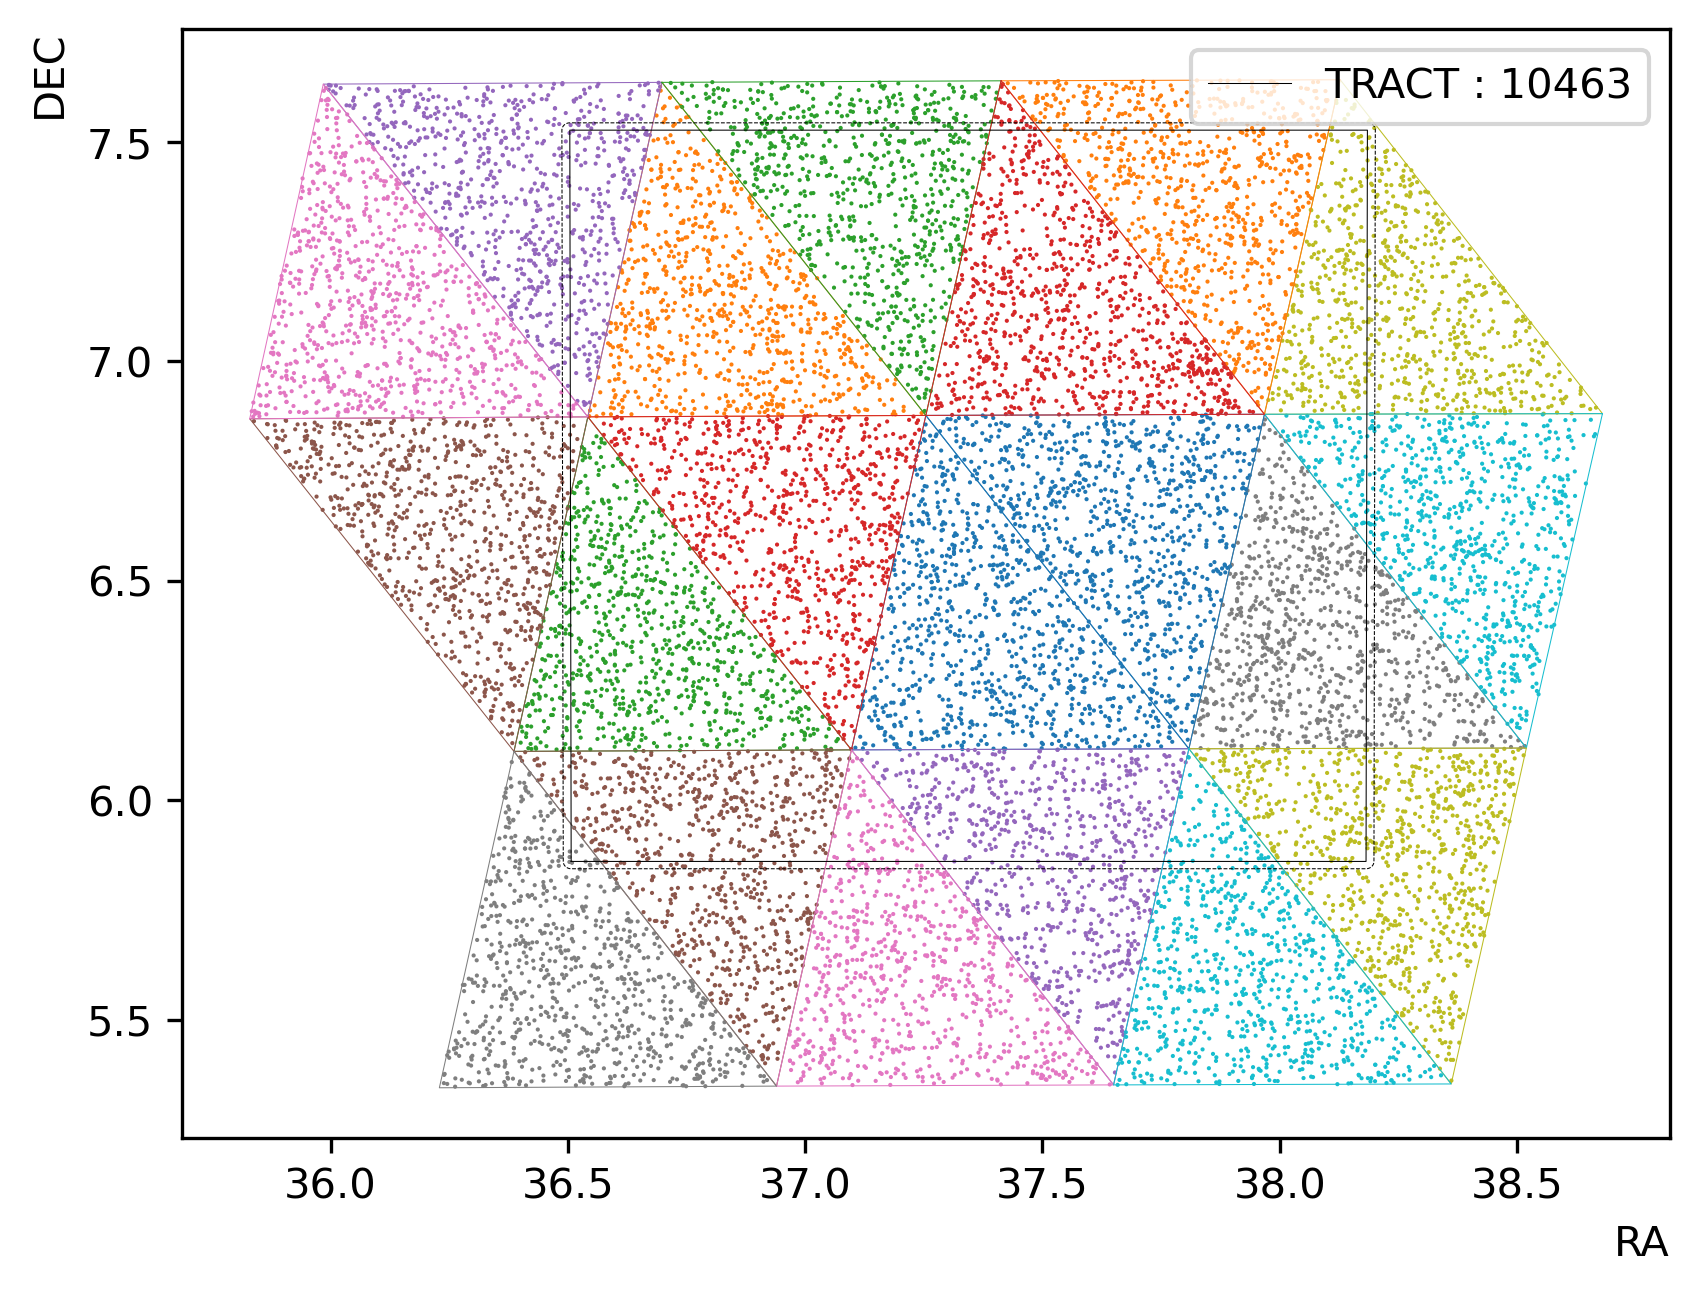

In [213]:
fig, axs = plt.subplots(dpi=300)

monster_butler = dafButler.Butler("embargo", collections="refcats")

tract_info = skymap[TRACT]
polygon = tract_info.getOuterSkyPolygon()
coords = polygon.getVertices()
tract_poly = shapely.Polygon(np.vstack(hp.vec2ang(np.vstack(coords), lonlat=True)).T)
tract_poly_buff = tract_poly.buffer(1/60)

htmMap = sphgeom.HtmPixelization(7)
for ID in htm_ids :
    poly = shapely.Polygon(np.vstack(hp.vec2ang(np.vstack(sphgeom.ConvexPolygon.getVertices(htmMap.triangle(ID))), lonlat=True)).T)
    if poly.intersects(tract_poly_buff) :
        x, y = poly.exterior.xy
        x = np.array(x.tolist())
        y = np.array(y.tolist())
        if np.all(np.cos(x * np.pi/180) > 0) & np.all(np.cos(x * np.pi/180) < 1) :
            plt.plot(x, y, lw=0.25)
            print(f'ID: {ID}, area: {poly.area}')

            monster_cat = monster_butler.get("the_monster_20250219", dataId={"htm7":int(ID)})
            plt.scatter(monster_cat['coord_ra'] * 180/np.pi, monster_cat['coord_dec'] * 180/np.pi, s=1, ec='none')
    del poly

    
    
x, y = tract_poly.exterior.xy
x = np.array(x.tolist())
y = np.array(y.tolist())
plt.plot(x, y, c='k', lw=0.25, label=f"TRACT : {TRACT}")

x, y = tract_poly_buff.exterior.xy
x = np.array(x.tolist())
y = np.array(y.tolist())
plt.plot(x, y, c='k', ls='--', lw=0.25)

plt.xlabel('RA', loc='right')
plt.ylabel('DEC', loc='top')
plt.legend();

## In HEALPix
We can also grab the Monster wedges overlapping a particular HEALPix based on the HEALPix ID.

In [214]:
hpix_id = 34037

In [215]:
htm_ids = hpix2htm_id(64, 7, hpix_id, buffer=1., nest=True)

ID: 144209, area: 0.6083332103300985
ID: 144210, area: 0.6158241932069112
ID: 144211, area: 0.6118169203886448
ID: 144221, area: 0.6234655748598894
ID: 144222, area: 0.6157938105722921
ID: 144223, area: 0.619947199155129
ID: 144322, area: 0.6096550547692656


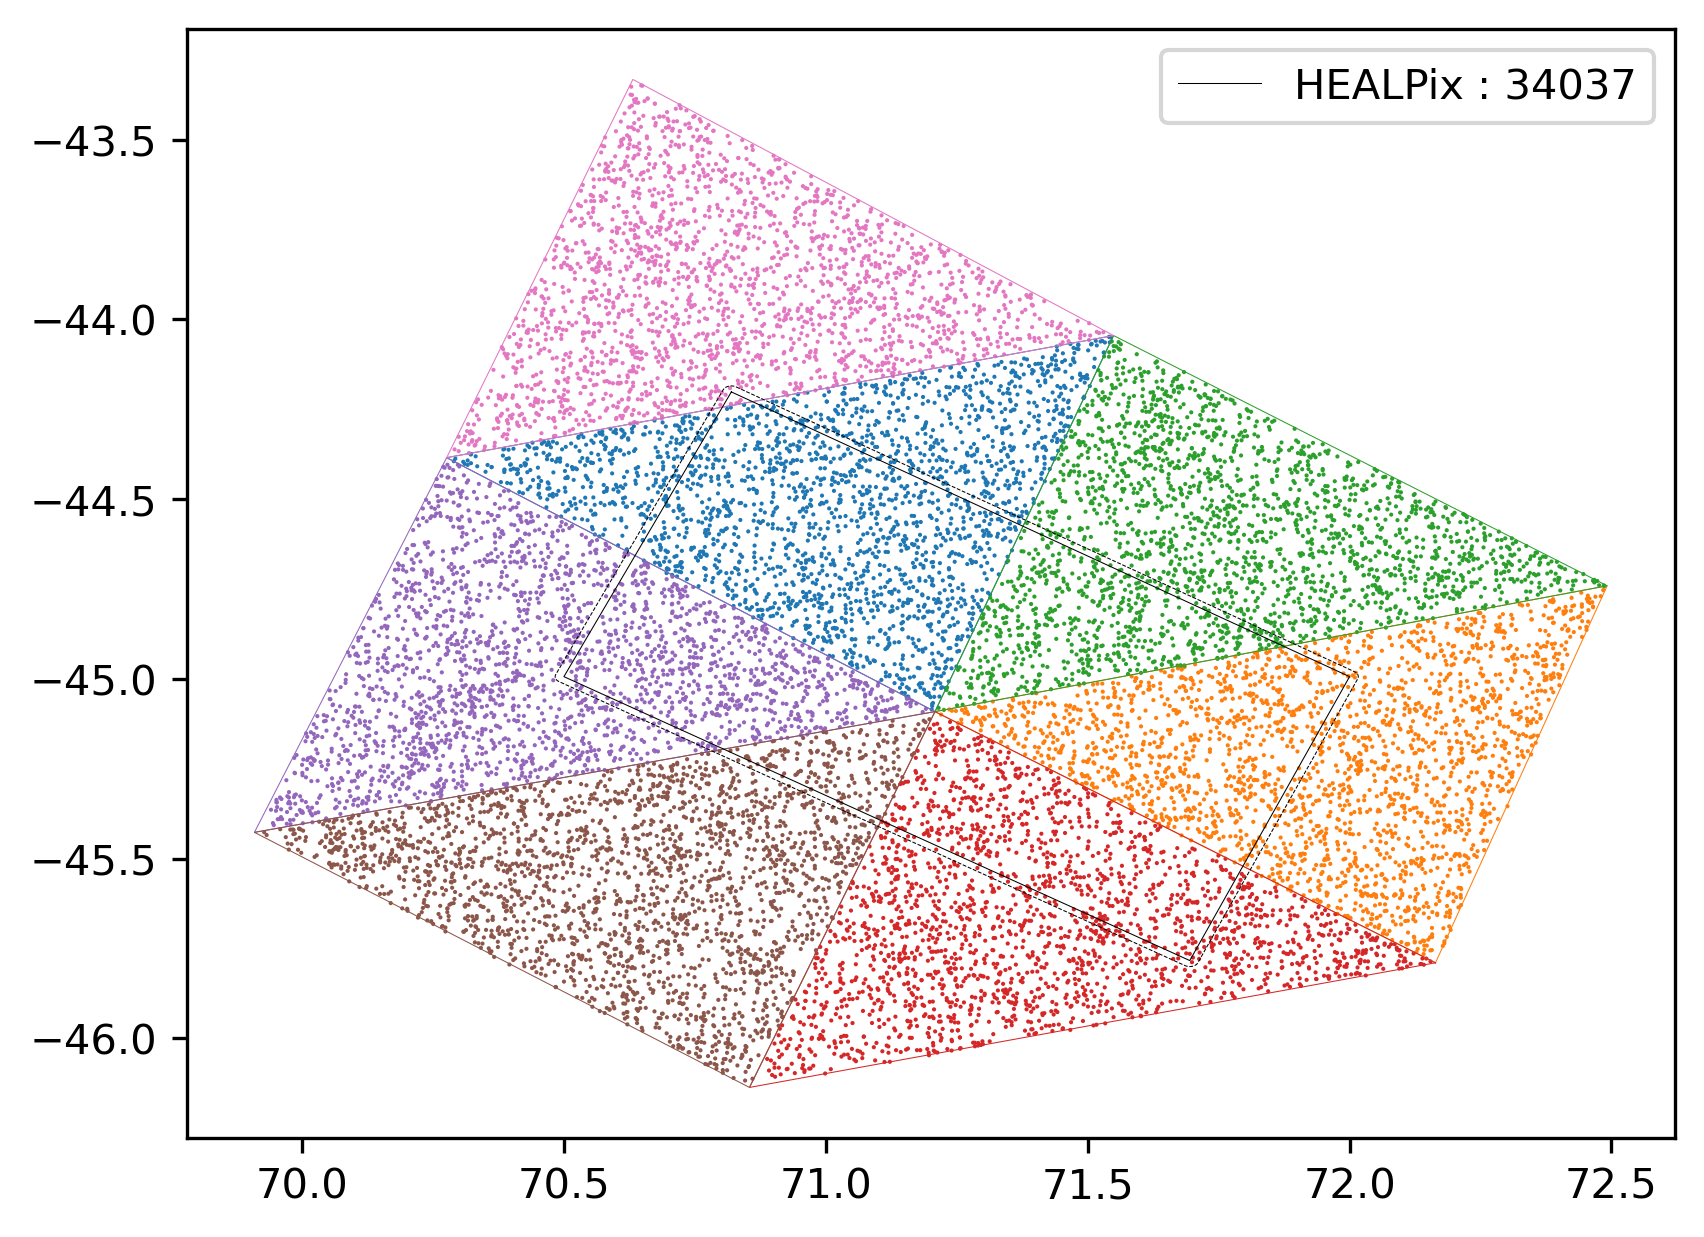

In [217]:
fig, axs = plt.subplots(dpi=300)

monster_butler = dafButler.Butler("embargo", collections="refcats")

hpix_poly = shapely.Polygon(np.array(hp.vec2ang(hp.boundaries(64, 34037, nest=True).T, lonlat=True)).T)
hpix_poly_buff = hpix_poly.buffer(1/60)

htmMap = sphgeom.HtmPixelization(7)
for ID in htm_ids :
    poly = shapely.Polygon(np.vstack(hp.vec2ang(np.vstack(sphgeom.ConvexPolygon.getVertices(htmMap.triangle(ID))), lonlat=True)).T)
    x, y = poly.exterior.xy
    x = np.array(x.tolist())
    y = np.array(y.tolist())
    if np.all(np.cos(x * np.pi/180) > 0) & np.all(np.cos(x * np.pi/180) < 1) :
        plt.plot(x, y, lw=0.25)
        print(f'ID: {ID}, area: {poly.area}')

        monster_cat = monster_butler.get("the_monster_20250219", dataId={"htm7":int(ID)})
        plt.scatter(monster_cat['coord_ra'] * 180/np.pi, monster_cat['coord_dec'] * 180/np.pi, s=1, ec='none')
    del poly

    
    
x, y = hpix_poly.exterior.xy
x = np.array(x.tolist())
y = np.array(y.tolist())
plt.plot(x, y, c='k', lw=0.25, label=f"HEALPix : {hpix_id}")

x, y = hpix_poly_buff.exterior.xy
x = np.array(x.tolist())
y = np.array(y.tolist())
plt.plot(x, y, c='k', ls='--', lw=0.25)

plt.legend();